<a href="https://colab.research.google.com/github/Carlos-A-Palomares/mis433/blob/main/text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [ ]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [ ]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [ ]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [ ]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [ ]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [ ]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [ ]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [ ]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


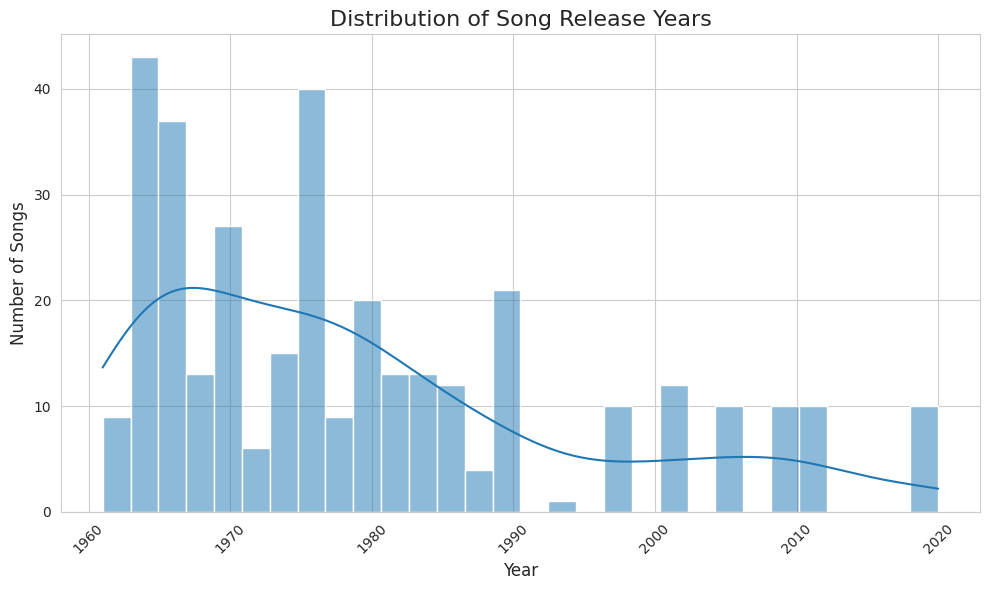

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [ ]:
import sklearn
print('scikit-learn is ready')


scikit-learn is ready


### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [ ]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [ ]:
# Size of the vocabulary
len(vocabulary)

7326

In [ ]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [ ]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [ ]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_1651/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


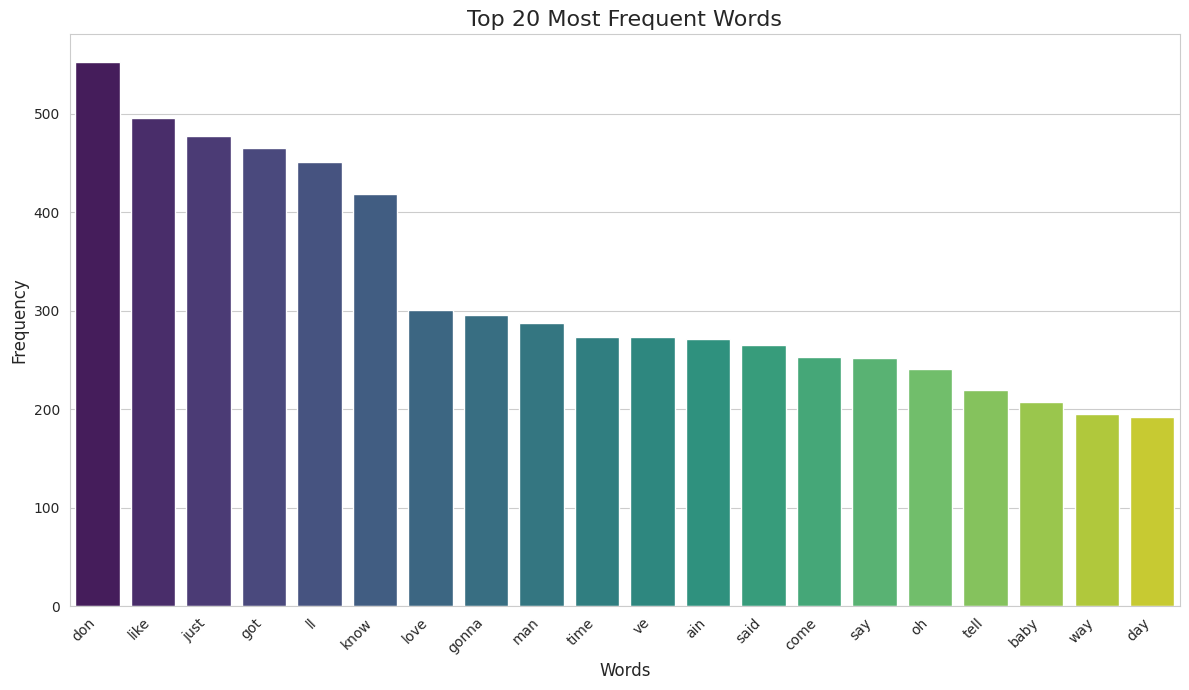

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [ ]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


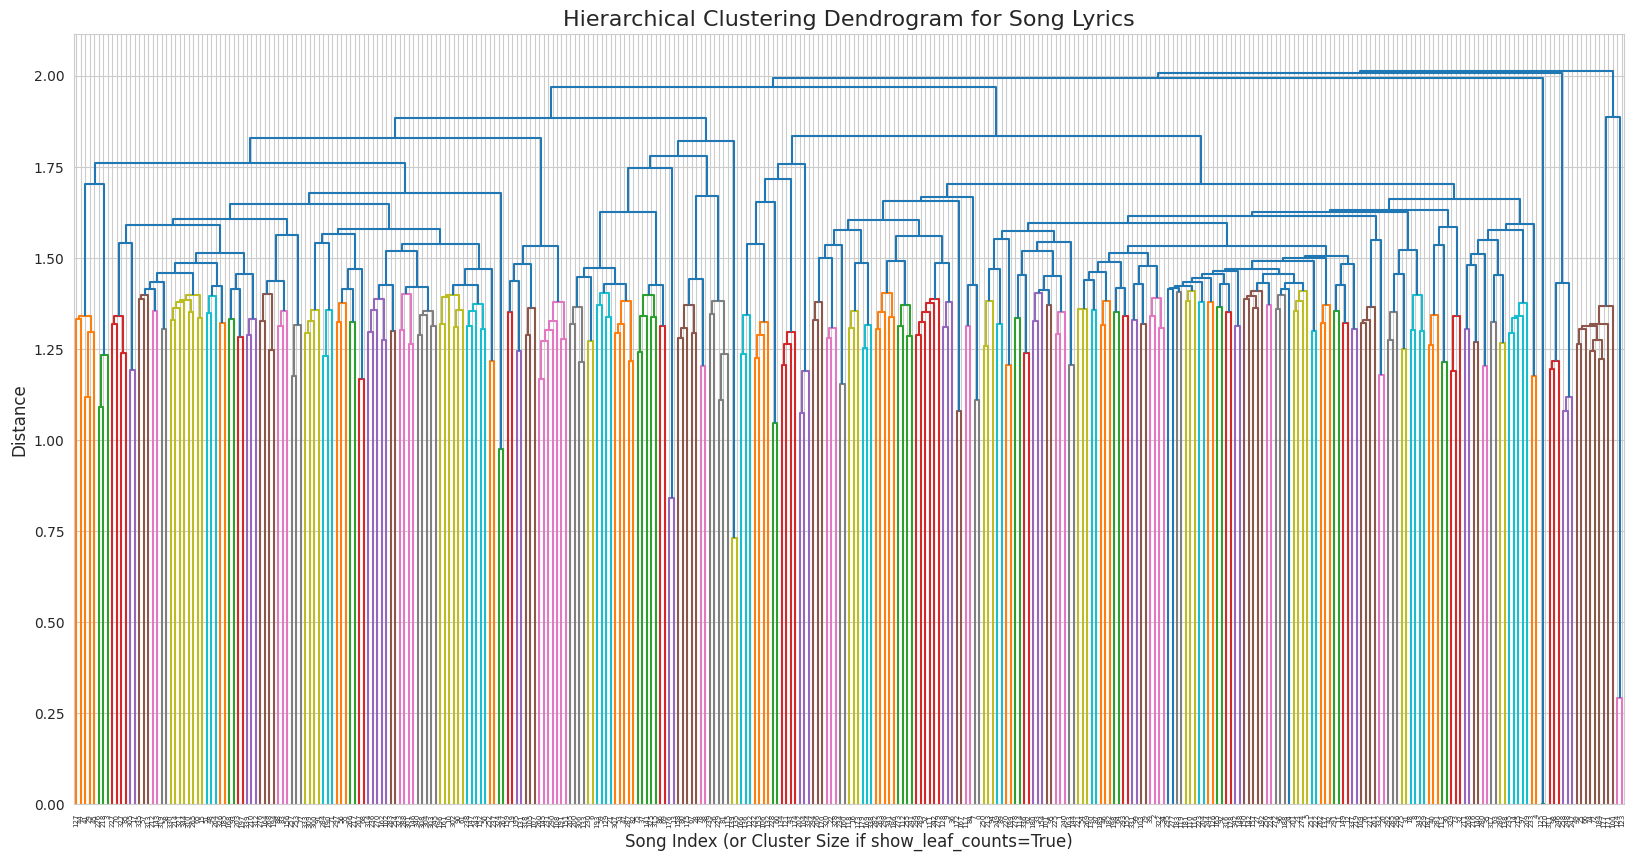

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [ ]:
import sys
import subprocess

try:
    from wordcloud import WordCloud
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wordcloud'])
    from wordcloud import WordCloud

print('wordcloud is ready')


wordcloud is ready


In [ ]:
from PIL import Image
print('Pillow is ready')


Pillow is ready


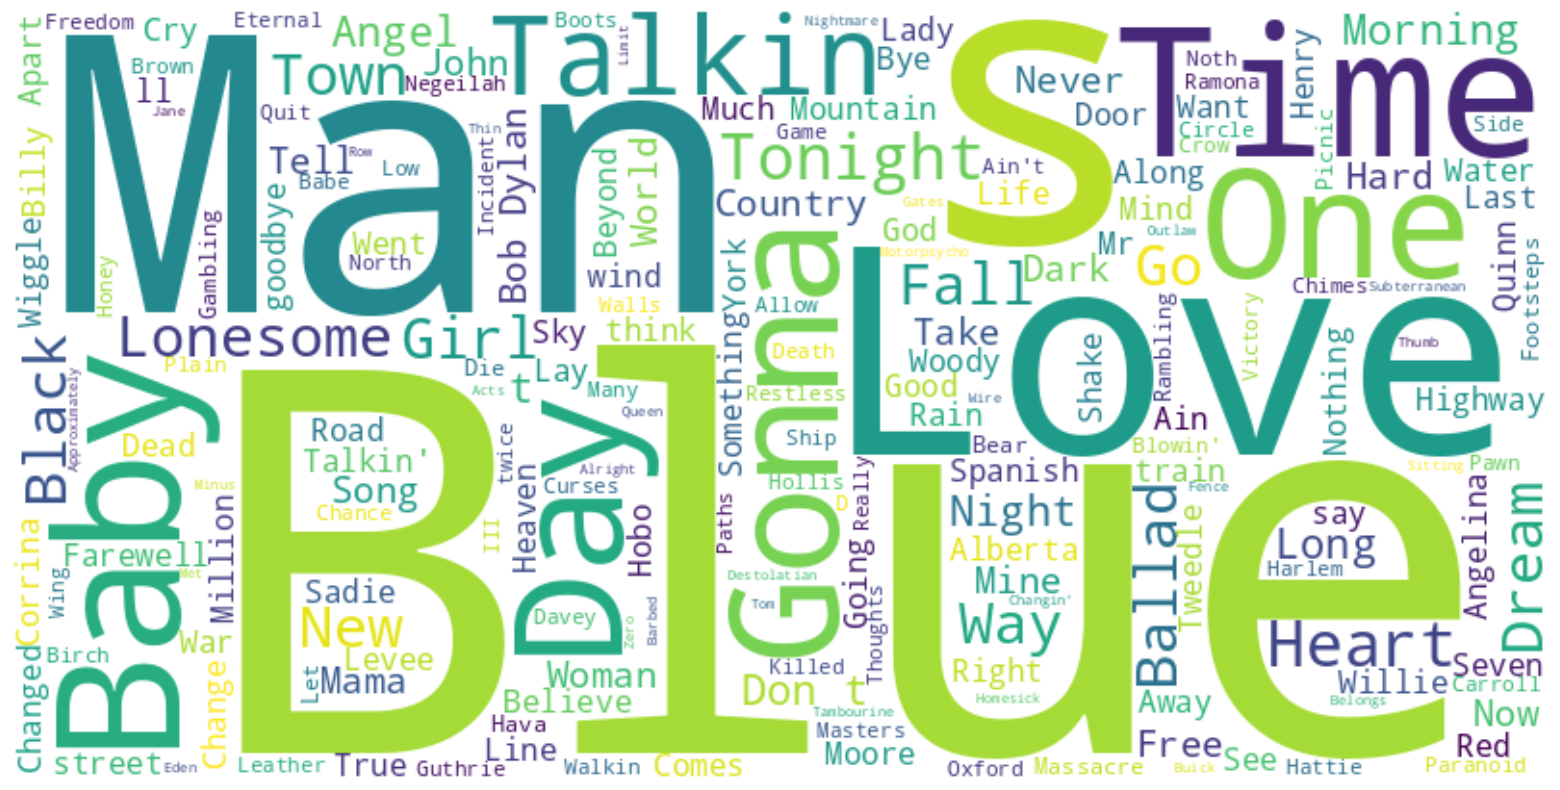

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_titles_text = " ".join(title for title in df['title'])
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


If the word cloud package has a Pillow compatibility issue, reinstall Pillow and wordcloud before running the word cloud cell again.


In [ ]:
import sys
import subprocess

try:
    from wordcloud import WordCloud
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wordcloud'])
    from wordcloud import WordCloud

print('wordcloud is ready')


wordcloud is ready


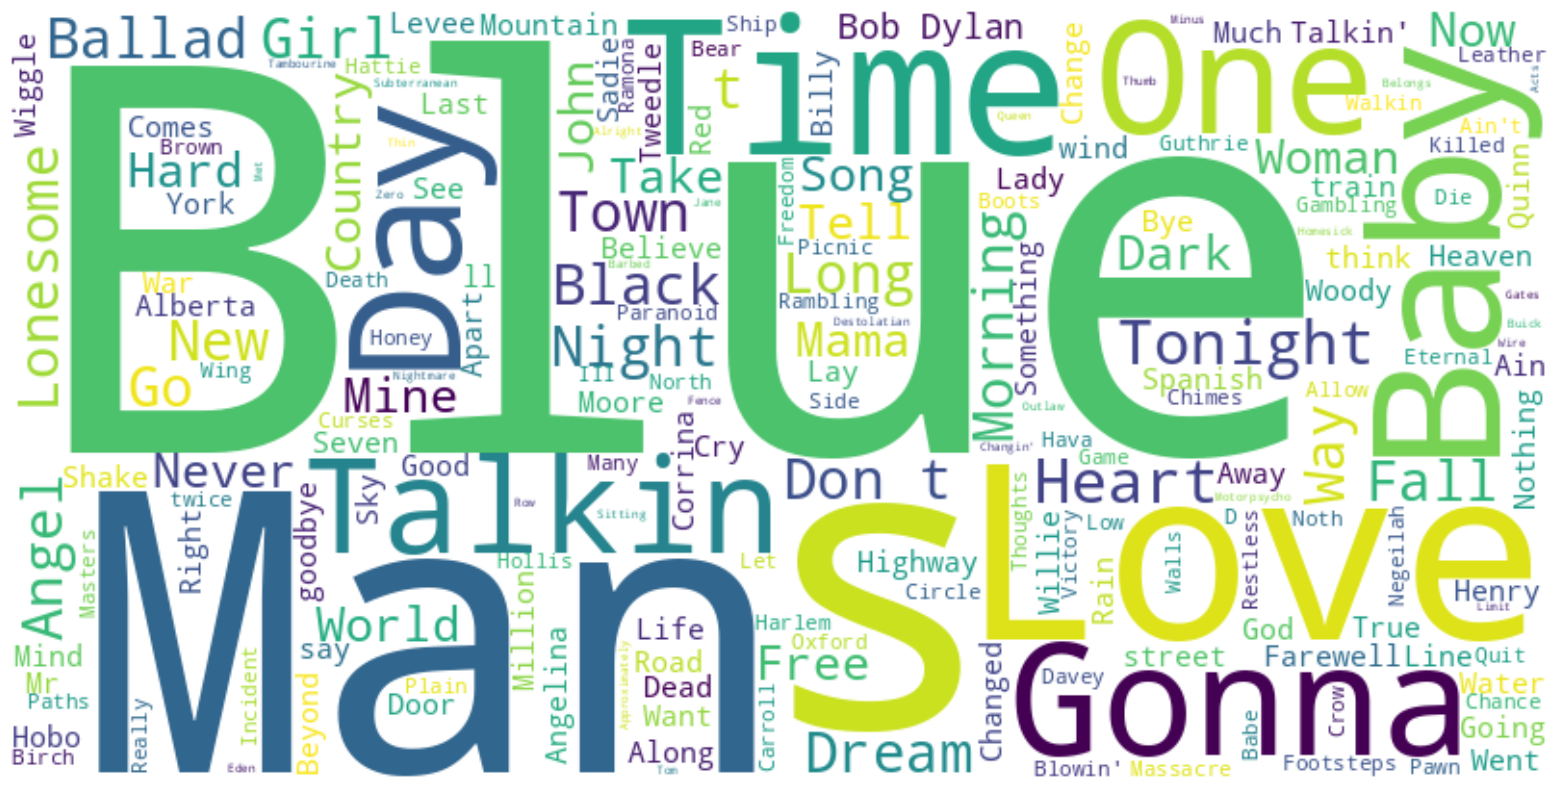

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_titles_text = " ".join(title for title in df['title'])
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [ ]:
import sys
import subprocess

try:
    from textblob import TextBlob
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'textblob'])
    from textblob import TextBlob

print('TextBlob is ready')


TextBlob is ready


In [ ]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [ ]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.

text_df = df.dropna(subset=['lyrics']).copy()

for decade, group in text_df.groupby('decade'):
    lyrics = group['lyrics'].tolist()
    vectorizer = CountVectorizer(stop_words='english')
    X_decade = vectorizer.fit_transform(lyrics)
    word_counts = X_decade.toarray().sum(axis=0)
    words = vectorizer.get_feature_names_out()
    top_words = pd.DataFrame({'word': words, 'count': word_counts})
    top_words = top_words.sort_values('count', ascending=False).head(10)
    print(decade)
    display(top_words)


1960


,word,count
1865,just,182
973,don,152
2017,like,142
2044,ll,138
1501,got,135
61,ain,127
1913,know,126
2952,said,103
659,come,88
2394,oh,84


1970


,word,count
1603,like,146
794,don,140
1187,gonna,125
1485,just,113
2362,said,98
1524,know,94
1628,ll,91
1919,oh,90
2880,time,89
3019,ve,85


1980


...

,word,count
592,got,77
378,don,57
809,ll,52
590,gonna,51
732,just,44
755,know,44
326,day,41
1189,say,41
8,ain,39
591,good,39


2010


,word,count
591,ll,44
592,long,32
76,blowin,22
1090,work,22
1048,way,20
577,like,18
469,heart,16
242,day,16
985,town,14
575,light,13


2020


,word,count
774,play,70
589,ll,47
521,key,27
246,don,26
1142,west,24
568,like,23
1112,ve,19
1027,tell,19
398,got,19
922,sing,18


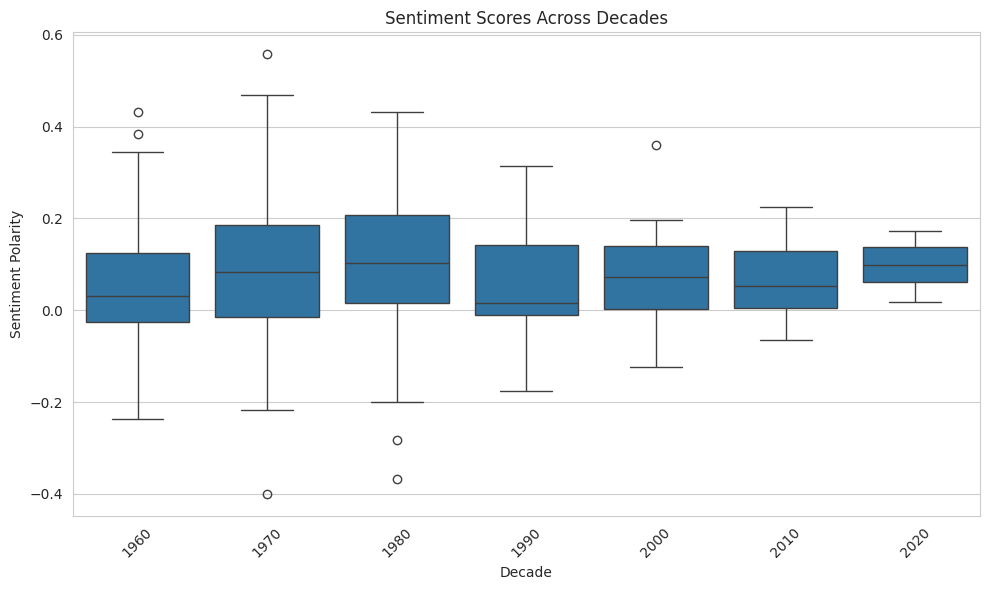

In [ ]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().

text_df['sentiment_polarity'] = text_df['lyrics'].apply(lambda lyrics: TextBlob(lyrics).sentiment.polarity)

plt.figure(figsize=(10, 6))
sns.boxplot(data=text_df, x='decade', y='sentiment_polarity')
plt.title('Sentiment Scores Across Decades')
plt.xlabel('Decade')
plt.ylabel('Sentiment Polarity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [ ]:
import os

try:
    from google.colab import userdata
    NEWS_API_KEY = userdata.get('NEWS_API_KEY')
except Exception:
    NEWS_API_KEY = os.environ.get('NEWS_API_KEY')

if not NEWS_API_KEY:
    NEWS_API_KEY = 'cc3fb4d1ae9d4686bad44604ecbc2bd8'

if NEWS_API_KEY:
    print('API Key found')
else:
    print('No NewsAPI key found')


API Key found


In [ ]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-29 to 2026-06-01


In [ ]:
import requests
import pandas as pd

query = 'music'
print(f'Searching for articles related to: {query}')

url = 'https://newsapi.org/v2/everything'

params = {
    'pageSize': 100,
    'apiKey': NEWS_API_KEY,
    'q': query,
    'from': from_param,
    'to': today.strftime('%Y-%m-%d'),
    'language': 'en'
}

news_df = pd.DataFrame(columns=['title', 'author', 'source', 'description', 'date'])

if NEWS_API_KEY:
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        articles_data = []
        for article in data.get('articles', []):
            source_name = article.get('source', {}).get('name', 'N/A')
            articles_data.append({
                'title': article.get('title'),
                'author': article.get('author'),
                'source': source_name,
                'description': article.get('description'),
                'date': article.get('publishedAt')
            })

        news_df = pd.DataFrame(articles_data)

        print('Successfully fetched news articles.')
        print(f'Total articles retrieved and saved to DataFrame: {len(news_df)}')
        print(f"Total results matching query: {data.get('totalResults', 0)}")
        display(news_df.head())

    except requests.exceptions.RequestException as e:
        print(f'Error fetching news: {e}')
        display(news_df)
else:
    print('No NewsAPI key was available, so no live articles were retrieved.')
    display(news_df)


Searching for articles related to: music
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 99
Total results matching query: 1270


,title,author,source,description,date
0,Feeble Little Horse leans into digital weirdne...,Terrence O’Brien,The Verge,"From the opening moments of bitknot, it's obvi...",2026-05-30T18:11:18Z
1,Listen to the new Steam Controller buzz to the...,Jay Peters,The Verge,You may have heard that Valve's new Steam Cont...,2026-05-30T14:02:51Z
2,Apple Music outage confirmed in multiple count...,Marcus Mendes,9to5Mac,Apple’s System Status pages in several countri...,2026-05-29T19:16:53Z
3,Apple Music could soon get different subscript...,Marcus Mendes,9to5Mac,"As spotted by Aaron Perris, Apple seems to be ...",2026-05-30T02:09:03Z
4,Yours Truly on TBPN Yesterday,John Gruber,YouTube,"Enjoy the videos and music you love, upload or...",2026-05-30T12:28:10Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

In [ ]:
common_words

,word,count
811,music,52
829,new,31
1264,trump,15
105,apple,14
485,freedom,13
25,250,13
531,great,13
443,fair,13
88,american,11
1141,state,11


In [ ]:
pd.concat(rows, ignore_index=True)

,source,word,count
0,Forbes,american,6
1,Forbes,state,6
2,Forbes,great,6
3,Forbes,fair,6
4,Forbes,music,5
5,Pitchfork,new,3
6,Pitchfork,iceage,2
7,Pitchfork,dj,2
8,Pitchfork,perry,2
9,Pitchfork,kurt,2


In [ ]:
sentiment_by_source

,count,mean
source,,
mindbodygreen.com,1,0.650000
Slickdeals.net,1,0.466667
New Atlas,1,0.450000
YouTube,1,0.425000
Loc.gov,1,0.422222
Consequence.net,3,0.406267
Spinmagazine.com,1,0.378788
The New Republic,1,0.378535
Variety,1,0.333333


In [ ]:
news_analysis[['title', 'source', 'cluster']].head(20)

,title,source,cluster
0,Feeble Little Horse leans into digital weirdne...,The Verge,0
1,Listen to the new Steam Controller buzz to the...,The Verge,0
2,Apple Music outage confirmed in multiple count...,9to5Mac,0
3,Apple Music could soon get different subscript...,9to5Mac,0
4,Yours Truly on TBPN Yesterday,YouTube,0
5,AI-Generated Film About Iranian Protest Violen...,CNET,1
6,Xiaomi Claims Watch S5 Has 21 Days of Battery ...,Gizmodo.com,0
7,WATCH: Spotify reveals song of summer predictions,Abcnews.com,0
8,The Internet Reacts To Mass Exodus Of Bret Mic...,Kotaku,2
9,"I know YouTube Music is flawed, yet I prefer i...",Android Authority,0
